In [1]:
import os
import sys
import requests
import datetime as dt
import numpy as np
from dotenv import load_dotenv
from pathlib import Path
import requests
import pandas as pd
import talib as ta
import plotly.graph_objs as go
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import Dropdown, Text, Button, Output
from IPython.display import display
from pathlib import Path

from Modules.utility import Utility
from Modules.show_plot import ShowPlot
from Modules.reques_api import RequestApi
from Modules.get_market_data import GetMarketData
from Modules.stock_prices_and_market_data import ClassStockPricesMarketData
from Modules.financial import Financial
from Modules.pdf_url_to_markdown import PDFUrlToMarkdown
from Modules.webpage_to_markdown import WebpageToMarkdown

In [2]:
API_BASE_URL = os.getenv("API_BASE_URL", "http://localhost:8000")
request_api = RequestApi(API_BASE_URL)
get_market_data = GetMarketData(Path('/workspace/data'))
utility = Utility()
stock_prices_market_data = ClassStockPricesMarketData()
financial = Financial()
# URLからPDFをダウンロードしてMarkdownに変換するクラスのインスタンスを作成
pdf_to_md = PDFUrlToMarkdown()
# WEBページをMarkdownに変換する関数
webpage_to_markdown = WebpageToMarkdown()

In [3]:
gold = 'GC=F'
start = '1999-01-01'
end = dt.datetime.now().strftime('%Y-%m-%d')
response = request_api.update_commodity_timeseries_data(
    code=gold,
    market=None,
    start=start,
    end=end
)
response

{'result': True}

In [4]:
gold_df = request_api.get_commodity_time_series_data(
    code=gold,
    market=None,
    start='2025-01-01',
    end=end
)
gold_df.head()

取得件数: 566


,id,commodity_id,commodity_code,commodity_market,date,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
0,5900,1,GC=F,None,2024-03-07,2158.000000,2163.000000,2147.000000,2147.000000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1,5901,1,GC=F,None,2024-03-08,2178.600098,2194.899902,2166.300049,2167.300049,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,5902,1,GC=F,None,2024-03-11,2182.500000,2184.000000,2177.199951,2181.000000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
3,5903,1,GC=F,None,2024-03-12,2160.399902,2182.699951,2160.399902,2182.500000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,5904,1,GC=F,None,2024-03-13,2175.399902,2175.399902,2162.500000,2162.500000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False


In [5]:
silver = 'SI=F'
start = '1999-01-01'
end = dt.datetime.now().strftime('%Y-%m-%d')
response = request_api.update_commodity_timeseries_data(
    code=silver,
    market=None,
    start=start,
    end=end
)
response

{'result': True}

In [6]:
silver_df = request_api.get_commodity_time_series_data(
    code=silver,
    market=None,
    start='2025-01-01',
    end=end
)
silver_df.head()

取得件数: 566


,id,commodity_id,commodity_code,commodity_market,date,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
0,12338,2,SI=F,None,2024-03-07,24.370001,24.514999,24.139999,24.165001,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1,12339,2,SI=F,None,2024-03-08,24.339001,24.504999,24.299999,24.504999,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,12340,2,SI=F,None,2024-03-11,24.511999,24.511999,24.370001,24.385000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
3,12341,2,SI=F,None,2024-03-12,24.194000,24.504999,24.194000,24.465000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,12342,2,SI=F,None,2024-03-13,24.959000,24.959000,24.215000,24.215000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False


In [7]:
def stock_prices_and_gold_prices(
        code: str,
        name: str,
        start: str,
        end: str,
        df_stock: pd.DataFrame | None = None,
        df_sp: pd.DataFrame | None = None,
        df_gold: pd.DataFrame | None = None,
        df_silver: pd.DataFrame | None = None
    ):
    # /api/v1/time_series_data/stock/
    if df_stock is None:
        response = request_api.get_stock_time_series_data(
            code=code,
            market=None,
            start=start,
            end=end
        )
        df_stock = pd.DataFrame(response)

    # S&P500を統合
    if df_sp is not None:
        df_sp_tmp = df_sp.copy() if df_sp is not None else pd.DataFrame()
        if "date" not in df_sp_tmp.columns:
            df_sp_tmp = df_sp_tmp.reset_index()

        df_sp_tmp["date"] = pd.to_datetime(df_sp_tmp["date"])
        df_sp_tmp = df_sp_tmp.set_index("date")
        df_sp_tmp = df_sp_tmp.loc[start:end]

    # 金価格を統合
    if df_gold is not None:
        df_gold_tmp = df_gold.copy() if df_gold is not None else pd.DataFrame()
        if "date" not in df_gold_tmp.columns:
            df_gold_tmp = df_gold_tmp.reset_index()
        df_gold_tmp["date"] = pd.to_datetime(df_gold_tmp["date"])
        df_gold_tmp = df_gold_tmp.set_index("date")
        df_gold_tmp = df_gold_tmp.loc[start:end]

    # 銀価格を統合
    if df_silver is not None:
        df_silver_tmp = df_silver.copy() if df_silver is not None else pd.DataFrame()
        if "date" not in df_silver_tmp.columns:
            df_silver_tmp = df_silver_tmp.reset_index()
        df_silver_tmp["date"] = pd.to_datetime(df_silver_tmp["date"])
        df_silver_tmp = df_silver_tmp.set_index("date")
        df_silver_tmp = df_silver_tmp.loc[start:end]

    # 金価格
    df = df_stock.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df = df.loc[start:end]


    # インデックスを揃えて結合
    if df_sp is not None:
        df["MA5_SP"] = df_sp_tmp["ma5"].reindex(df.index)
        df["MA25_SP"] = df_sp_tmp["ma25"].reindex(df.index)
    if df_gold is not None:
        df["MA5_GOLD"] = df_gold_tmp["ma5"].reindex(df.index)
        df["MA25_GOLD"] = df_gold_tmp["ma25"].reindex(df.index)
    if df_silver is not None:
        df["MA5_SILVER"] = df_silver_tmp["ma5"].reindex(df.index)
        df["MA25_SILVER"] = df_silver_tmp["ma25"].reindex(df.index)

    show_plot = ShowPlot()
    fig = show_plot.create_basic_chart(
        df=df.reset_index(),
        code=code,
        name=name,
        start=start,
        end=end
    )
    # ★ 2つのY軸を定義（左：HYMC、右：SP500 & GOLD）
    fig.update_layout(
        yaxis=dict(
            title=f"{name} Price",
            side="left"
        ),
        yaxis2=dict(
            title="SP500 / GOLD",
            overlaying="y",
            side="right"
        )
    )

    # --- SP500（右軸） ---
    if df_sp is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_SP"],
                name="SP_MA5",
                line={"color": "blue", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_SP"],
                name="SP_MA25",
                line={"color": "gray", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )

    # --- GOLD（右軸） ---
    if df_gold is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_GOLD"],
                name="GOLD_MA5",
                line={"color": "orange", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_GOLD"],
                name="GOLD_MA25",
                line={"color": "yellow", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )

    # --- SILVER（左軸） ---
    if df_silver is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_SILVER"],
                name="SILVER_MA5",
                line={"color": "gray", "width": 1.2},
                yaxis="y"   # ★ 左軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_SILVER"],
                name="SILVER_MA25",
                line={"color": "black", "width": 1.2},
                yaxis="y"   # ★ 左軸
            )
        )

    return fig

In [8]:
name = "Gold Price"
start = dt.datetime(2026, 1, 1).strftime("%Y-%m-%d")
end = dt.datetime.now().strftime('%Y-%m-%d')
# グラフ領域の作成
fig = stock_prices_and_gold_prices(
    code=gold,
    name=name,
    start=start,
    end=end,
    df_stock=gold_df,
    df_sp=None,
    df_gold=None,
    df_silver=None
)
fig.show()

In [9]:
# 例: すでに作成済みの fig を保存
output_dir = Path("/workspace/data/figures")
output_dir.mkdir(parents=True, exist_ok=True)
# ファイル名にコードと期間を含める
output_path = output_dir / f"{gold}_{start}_{end}.png"
fig.write_image(str(output_path), width=1600, height=900, scale=2)
# 保存完了のメッセージを表示
print("saved:", output_path)

saved: /workspace/data/figures/GC=F_2026-01-01_2026-06-08.png


In [10]:
name = "Silver Price"
start = dt.datetime(2026, 1, 1).strftime("%Y-%m-%d")
end = dt.datetime.now().strftime('%Y-%m-%d')
# グラフ領域の作成
fig = stock_prices_and_gold_prices(
    code=silver,
    name=name,
    start=start,
    end=end,
    df_stock=silver_df,
    df_sp=None,
    df_gold=None,
    df_silver=None
)
fig.show()

In [11]:
# 例: すでに作成済みの fig を保存
output_dir = Path("/workspace/data/figures")
output_dir.mkdir(parents=True, exist_ok=True)
# ファイル名にコードと期間を含める
output_path = output_dir / f"{silver}_{start}_{end}.png"
fig.write_image(str(output_path), width=1600, height=900, scale=2)
# 保存完了のメッセージを表示
print("saved:", output_path)

saved: /workspace/data/figures/SI=F_2026-01-01_2026-06-08.png


In [12]:
def compute_fibonacci_extension(
        df: pd.DataFrame, 
        price_col: str = "close", 
        high: float = None, 
        low: float = None, 
        lookback: int = 120
    ):
    """
    フィボナッチ・エクステンションを計算し、グラフ描画オブジェクトとともに返すメソッド。
    下方向（安値側）と上方向（高値側）の両方のターゲットを計算する。

    Returns
    -------
    dict
        {
            "fib_levels_down": dict,
            "fib_levels_up": dict,
            "swing_high": float,
            "swing_low": float,
            "df_with_fib": pandas.DataFrame,
            "plot_obj": matplotlib.figure.Figure
        }
    """

    # --- 1. スイング高値・安値の決定 ---
    if high is None:
        swing_high = df["high"].tail(lookback).max()
    else:
        swing_high = high

    if low is None:
        swing_low = df["low"].tail(lookback).min()
    else:
        swing_low = low

    # --- 2. フィボナッチ・エクステンション計算 ---
    diff = swing_high - swing_low

    # 下方向（安値側）
    fib_levels_down = {
        "1.000": swing_low,
        "1.272": swing_low - 0.272 * diff,
        "1.382": swing_low - 0.382 * diff,
        "1.618": swing_low - 0.618 * diff,
    }

    # 上方向（高値側）
    fib_levels_up = {
        "1.272": swing_high + 0.272 * diff,
        "1.382": swing_high + 0.382 * diff,
        "1.618": swing_high + 0.618 * diff,
        "2.000": swing_high + 1.000 * diff,  # 強いトレンド用
    }

    # --- 3. DataFrame にフィボナッチ値を追加 ---
    df = df.copy()
    for name, value in fib_levels_down.items():
        df[f"fib_down_{name}"] = value
    for name, value in fib_levels_up.items():
        df[f"fib_up_{name}"] = value

    # --- 4. グラフ描画 ---
    fig, ax = plt.subplots(figsize=(14, 6))

    # 時系列価格
    ax.plot(df["date"], df[price_col], label="Price", color="black")

    # 下方向エクステンション
    for name, value in fib_levels_down.items():
        ax.hlines(
            value,
            xmin=df["date"].min(),
            xmax=df["date"].max(),
            linestyles="dashed",
            colors="red",
            label=f"Fib Down {name}"
        )

    # 上方向エクステンション
    for name, value in fib_levels_up.items():
        ax.hlines(
            value,
            xmin=df["date"].min(),
            xmax=df["date"].max(),
            linestyles="dashed",
            colors="blue",
            label=f"Fib Up {name}"
        )

    # スイング高値・安値のマーカー
    ax.scatter(df["date"].iloc[-1], swing_low, color="red", label="Swing Low")
    ax.scatter(df["date"].iloc[-1], swing_high, color="green", label="Swing High")

    ax.set_title("Fibonacci Extension Projection (Up & Down)")
    ax.legend()
    ax.grid(True)
    fig.autofmt_xdate()

    # --- 5. 結果を返す ---
    return {
        "fib_levels_down": fib_levels_down,
        "fib_levels_up": fib_levels_up,
        "swing_high": swing_high,
        "swing_low": swing_low,
        "df_with_fib": df,
        "plot_obj": fig
    }


### SLV

In [13]:
output_dir = Path("/workspace/data/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"silver_data_{dt.datetime.now().strftime("%Y-%m-%d")}.csv"

df = silver_df.copy()
end = dt.datetime.now().strftime('%Y-%m-%d')
df = df.reset_index()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.loc['2026-01-01':end]
df.to_csv(output_path)
df.head()

,index,id,commodity_id,commodity_code,commodity_market,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,459,12797,2,SI=F,None,70.556000,73.589996,70.556000,71.375000,None,...,65.000000,96.512821,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-05,460,12798,2,SI=F,None,76.164001,76.820000,73.904999,74.175003,None,...,46.666667,95.760684,True,NaN,NaN,NaN,NaN,NaN,96.034188,False
2026-01-06,461,12799,2,SI=F,None,80.529999,80.855003,75.930000,75.930000,None,...,38.333333,95.418803,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-07,462,12800,2,SI=F,None,77.135002,80.900002,75.875000,80.900002,None,...,38.333333,95.418803,True,NaN,NaN,NaN,NaN,96.666667,NaN,False
2026-01-08,463,12801,2,SI=F,None,74.716003,76.570000,73.165001,76.570000,None,...,38.333333,94.871795,True,NaN,NaN,NaN,NaN,NaN,95.965812,False


{'fib_levels_down': {'1.000': np.float64(61.09000015258789),
  '1.272': np.float64(44.71287936401367),
  '1.382': np.float64(38.089779045104976),
  '1.618': np.float64(23.880218360900876)},
 'fib_levels_up': {'1.272': np.float64(137.67712384033203),
  '1.382': np.float64(144.3002241592407),
  '1.618': np.float64(158.50978484344483),
  '2.000': np.float64(181.51000595092773)},
 'swing_high': np.float64(121.30000305175781),
 'swing_low': np.float64(61.09000015258789),
 'df_with_fib':           date  index     id  commodity_id commodity_code commodity_market  \
 0   2026-01-02    459  12797             2           SI=F             None   
 1   2026-01-05    460  12798             2           SI=F             None   
 2   2026-01-06    461  12799             2           SI=F             None   
 3   2026-01-07    462  12800             2           SI=F             None   
 4   2026-01-08    463  12801             2           SI=F             None   
 ..         ...    ...    ...           

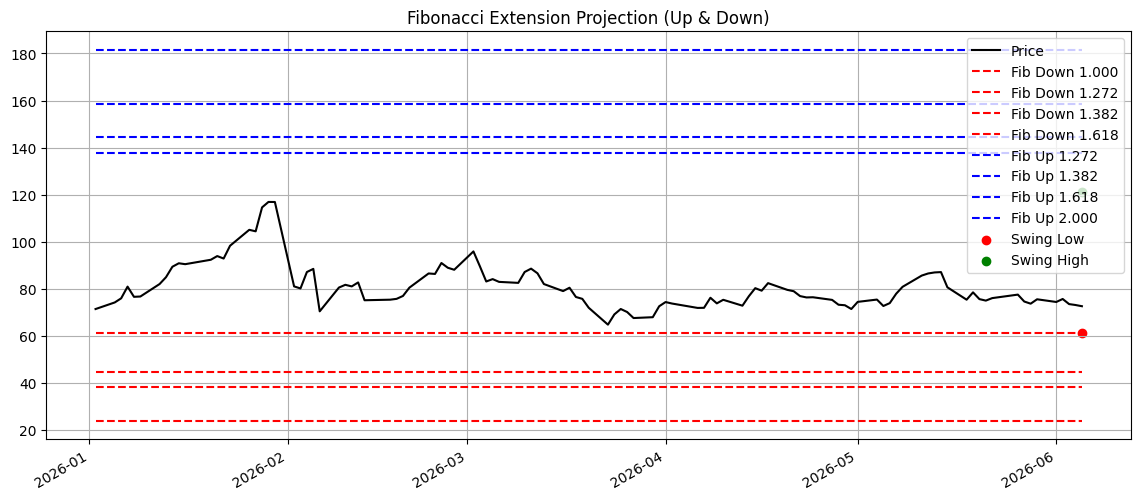

In [14]:
fib_result = compute_fibonacci_extension(df.copy().reset_index())
fib_result 

In [ ]:
output_dir = Path("/workspace/data/figures/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"silver_fibonacci_extension_{dt.datetime.now().strftime('%Y-%m-%d')}.png"
fib_result["plot_obj"].savefig(output_path, dpi=300, bbox_inches="tight")

### GOLD

In [15]:
output_dir = Path("/workspace/data/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"gold_data_{dt.datetime.now().strftime("%Y-%m-%d")}.csv"

df = gold_df.copy()
end = dt.datetime.now().strftime('%Y-%m-%d')
df = df.reset_index()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.loc['2026-01-01':end]
df.to_csv(output_path)
df.head()

,index,id,commodity_id,commodity_code,commodity_market,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,459,6359,1,GC=F,None,4314.399902,4350.600098,4314.399902,4350.600098,None,...,-35.000000,88.512821,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-05,460,6360,1,GC=F,None,4436.899902,4443.500000,4384.799805,4386.700195,None,...,-43.333333,87.350427,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-06,461,6361,1,GC=F,None,4482.200195,4482.200195,4449.000000,4449.700195,None,...,-48.333333,85.914530,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-07,462,6362,1,GC=F,None,4449.299805,4450.000000,4449.299805,4450.000000,None,...,-16.666667,84.273504,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-08,463,6363,1,GC=F,None,4449.700195,4461.299805,4418.000000,4460.200195,None,...,28.333333,84.273504,True,NaN,NaN,NaN,NaN,NaN,NaN,False


{'fib_levels_down': {'1.000': np.float64(4100.7998046875),
  '1.272': np.float64(3696.7708984375),
  '1.382': np.float64(3533.37685546875),
  '1.618': np.float64(3182.82236328125)},
 'fib_levels_up': {'1.272': np.float64(5990.2291015625),
  '1.382': np.float64(6153.62314453125),
  '1.618': np.float64(6504.17763671875),
  '2.000': np.float64(7071.6005859375)},
 'swing_high': np.float64(5586.2001953125),
 'swing_low': np.float64(4100.7998046875),
 'df_with_fib':           date  index     id  commodity_id commodity_code commodity_market  \
 0   2026-01-02    459   6359             1           GC=F             None   
 1   2026-01-05    460   6360             1           GC=F             None   
 2   2026-01-06    461   6361             1           GC=F             None   
 3   2026-01-07    462   6362             1           GC=F             None   
 4   2026-01-08    463   6363             1           GC=F             None   
 ..         ...    ...    ...           ...            ...    

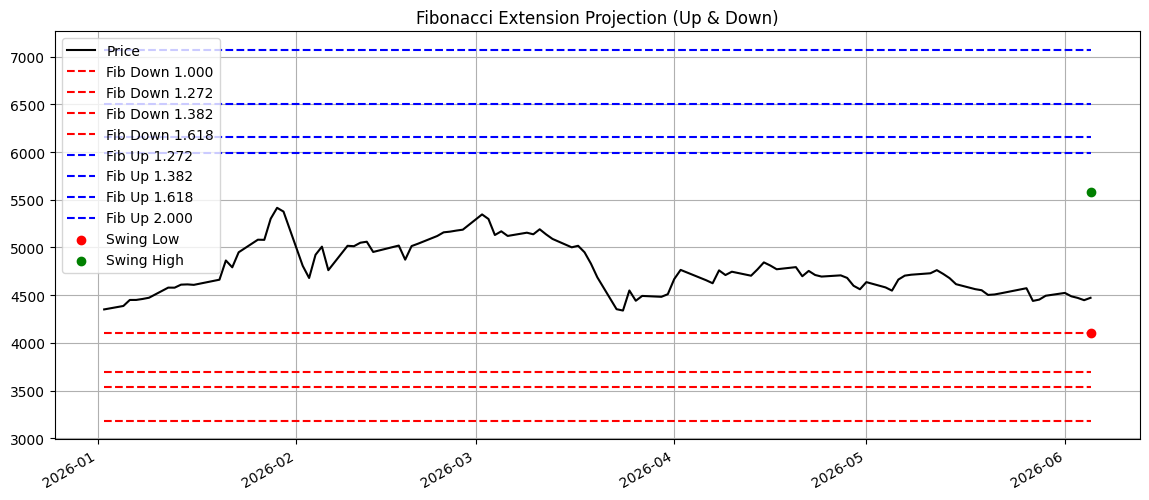

In [16]:
fib_result = compute_fibonacci_extension(df.copy().reset_index())
fib_result 

In [ ]:
output_dir = Path("/workspace/data/figures/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"gold_fibonacci_extension_{dt.datetime.now().strftime('%Y-%m-%d')}.png"
fib_result["plot_obj"].savefig(output_path, dpi=300, bbox_inches="tight")

In [17]:
md_file_path =pdf_to_md.pdf_url_to_markdown(
    pdf_url='',
    directory_path="/workspace/data",
)
md_file_path

MissingSchema: Invalid URL '': No scheme supplied. Perhaps you meant https://?